# Compare TreeCorr measurements: with vs. without randoms

Compares datavectors and JK covariance matrices from `test_treecorr` (no randoms subtraction) and `test_treecorr_random` (with randoms subtraction via `ng.calculateXi(rg=rg)`).

Both run on sim `000`, patchN=2 (two sky halves).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

DIR_NO_RAN  = 'test_treecorr/'
DIR_WITH_RAN = 'test_treecorr_random/'

SIM = '000'
PATCH_N = 2
PATCHES = [0, 1]

In [2]:
def load_datavector(directory, sim, patch_n, patch_id):
    fname = f'{directory}datavector_{sim}_patchN{patch_n}_{patch_id}.txt'
    data = np.loadtxt(fname, comments='#')
    # columns: r_nom, meanr, meanlogr, gamT, gamX, sigma, weight, npairs
    cols = ['r_nom', 'meanr', 'meanlogr', 'gamT', 'gamX', 'sigma', 'weight', 'npairs']
    return {c: data[:, i] for i, c in enumerate(cols)}

def load_cov(directory, sim, patch_n, patch_id):
    fname = f'{directory}cov_{sim}_patchN{patch_n}_{patch_id}.txt'
    return np.loadtxt(fname)

def cov_to_corr(cov):
    diag = np.sqrt(np.diag(cov))
    with np.errstate(invalid='ignore'):
        corr = cov / np.outer(diag, diag)
    corr[~np.isfinite(corr)] = 0.0
    return corr

## 1. Shear profiles (gamT vs r)

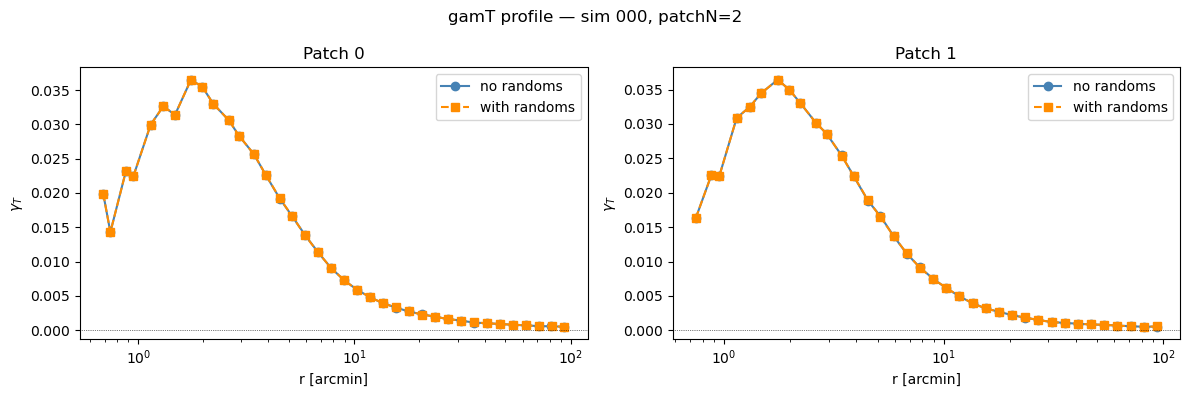

In [3]:
fig, axes = plt.subplots(1, len(PATCHES), figsize=(6 * len(PATCHES), 4), sharey=False)

for ax, patch_id in zip(axes, PATCHES):
    dv_no  = load_datavector(DIR_NO_RAN,   SIM, PATCH_N, patch_id)
    dv_ran = load_datavector(DIR_WITH_RAN, SIM, PATCH_N, patch_id)

    mask_no  = dv_no['npairs']  > 0
    mask_ran = dv_ran['npairs'] > 0

    ax.plot(dv_no['meanr'][mask_no],   dv_no['gamT'][mask_no],
            'o-', label='no randoms',   color='steelblue')
    ax.plot(dv_ran['meanr'][mask_ran], dv_ran['gamT'][mask_ran],
            's--', label='with randoms', color='darkorange')

    ax.axhline(0, color='k', lw=0.5, ls=':')
    ax.set_xscale('log')
    ax.set_xlabel('r [arcmin]')
    ax.set_ylabel(r'$\gamma_T$')
    ax.set_title(f'Patch {patch_id}')
    ax.legend()

fig.suptitle(f'gamT profile — sim {SIM}, patchN={PATCH_N}')
plt.tight_layout()
plt.show()

## 2. gamT relative difference (with randoms − no randoms) / no randoms

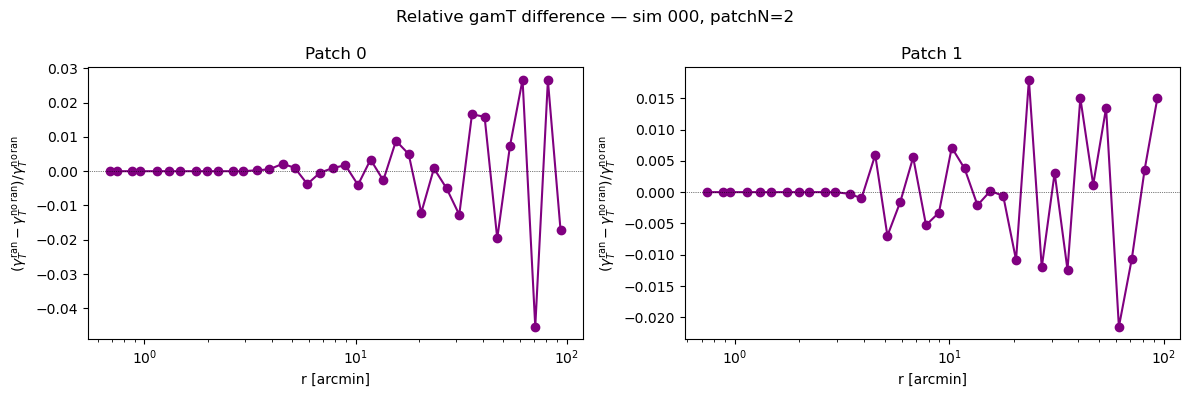

In [4]:
fig, axes = plt.subplots(1, len(PATCHES), figsize=(6 * len(PATCHES), 4), sharey=False)

for ax, patch_id in zip(axes, PATCHES):
    dv_no  = load_datavector(DIR_NO_RAN,   SIM, PATCH_N, patch_id)
    dv_ran = load_datavector(DIR_WITH_RAN, SIM, PATCH_N, patch_id)

    mask = (dv_no['npairs'] > 0) & (dv_ran['npairs'] > 0) & (dv_no['gamT'] != 0)
    r        = dv_no['meanr'][mask]
    rel_diff = (dv_ran['gamT'][mask] - dv_no['gamT'][mask]) / dv_no['gamT'][mask]

    ax.plot(r, rel_diff, 'o-', color='purple')
    ax.axhline(0, color='k', lw=0.5, ls=':')
    ax.set_xscale('log')
    ax.set_xlabel('r [arcmin]')
    ax.set_ylabel(r'$(\gamma_T^{\rm ran} - \gamma_T^{\rm no\,ran}) / \gamma_T^{\rm no\,ran}$')
    ax.set_title(f'Patch {patch_id}')

fig.suptitle(f'Relative gamT difference — sim {SIM}, patchN={PATCH_N}')
plt.tight_layout()
plt.show()

## 3. gamX (B-mode) profiles

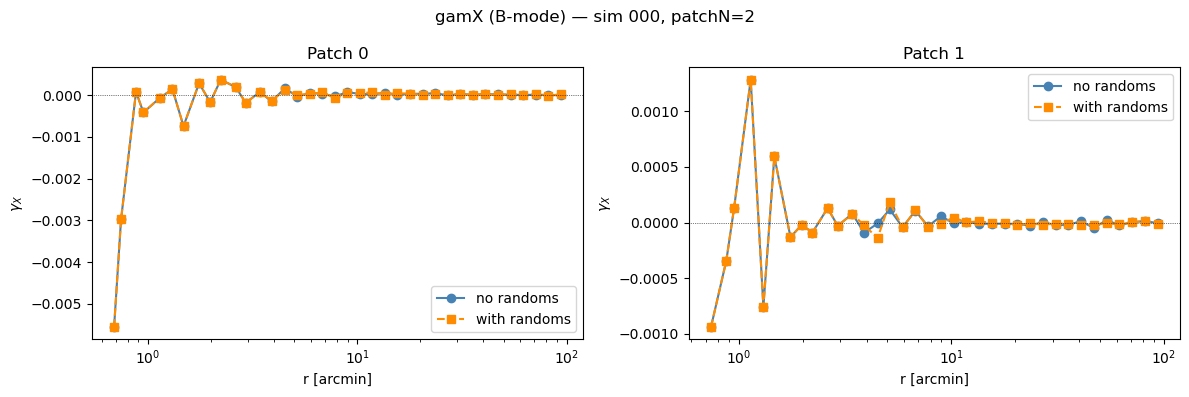

In [5]:
fig, axes = plt.subplots(1, len(PATCHES), figsize=(6 * len(PATCHES), 4), sharey=False)

for ax, patch_id in zip(axes, PATCHES):
    dv_no  = load_datavector(DIR_NO_RAN,   SIM, PATCH_N, patch_id)
    dv_ran = load_datavector(DIR_WITH_RAN, SIM, PATCH_N, patch_id)

    mask_no  = dv_no['npairs']  > 0
    mask_ran = dv_ran['npairs'] > 0

    ax.plot(dv_no['meanr'][mask_no],   dv_no['gamX'][mask_no],
            'o-', label='no randoms',   color='steelblue')
    ax.plot(dv_ran['meanr'][mask_ran], dv_ran['gamX'][mask_ran],
            's--', label='with randoms', color='darkorange')

    ax.axhline(0, color='k', lw=0.5, ls=':')
    ax.set_xscale('log')
    ax.set_xlabel('r [arcmin]')
    ax.set_ylabel(r'$\gamma_X$')
    ax.set_title(f'Patch {patch_id}')
    ax.legend()

fig.suptitle(f'gamX (B-mode) — sim {SIM}, patchN={PATCH_N}')
plt.tight_layout()
plt.show()

## 4. Covariance matrices

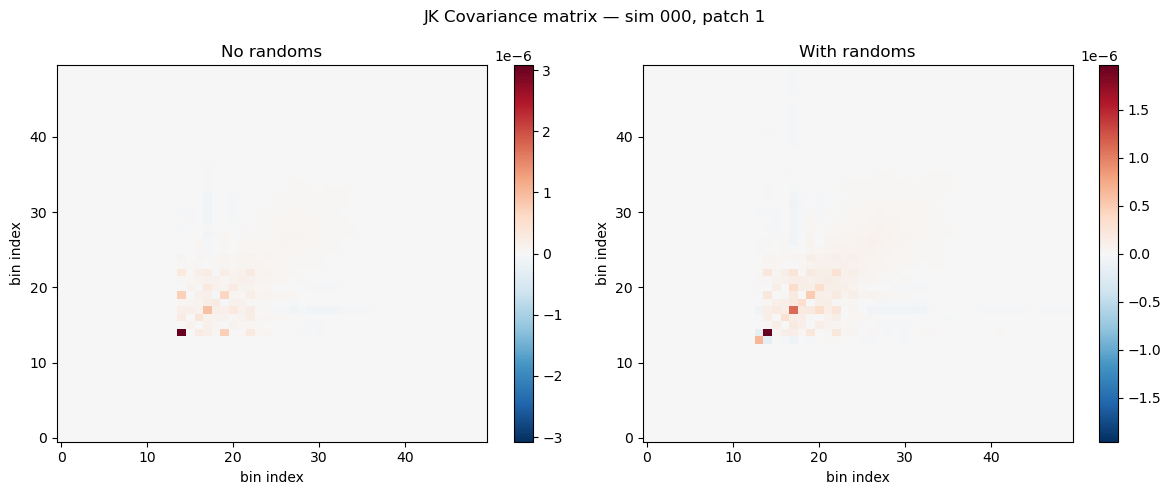

In [6]:
patch_id = 1

cov_no  = load_cov(DIR_NO_RAN,   SIM, PATCH_N, patch_id)
cov_ran = load_cov(DIR_WITH_RAN, SIM, PATCH_N, patch_id)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, cov, title in zip(axes, [cov_no, cov_ran], ['No randoms', 'With randoms']):
    im = ax.imshow(cov, origin='lower', aspect='auto', cmap='RdBu_r',
                   vmin=-np.abs(cov).max(), vmax=np.abs(cov).max())
    plt.colorbar(im, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('bin index')
    ax.set_ylabel('bin index')

fig.suptitle(f'JK Covariance matrix — sim {SIM}, patch {patch_id}')
plt.tight_layout()
plt.show()

## 5. Correlation matrices

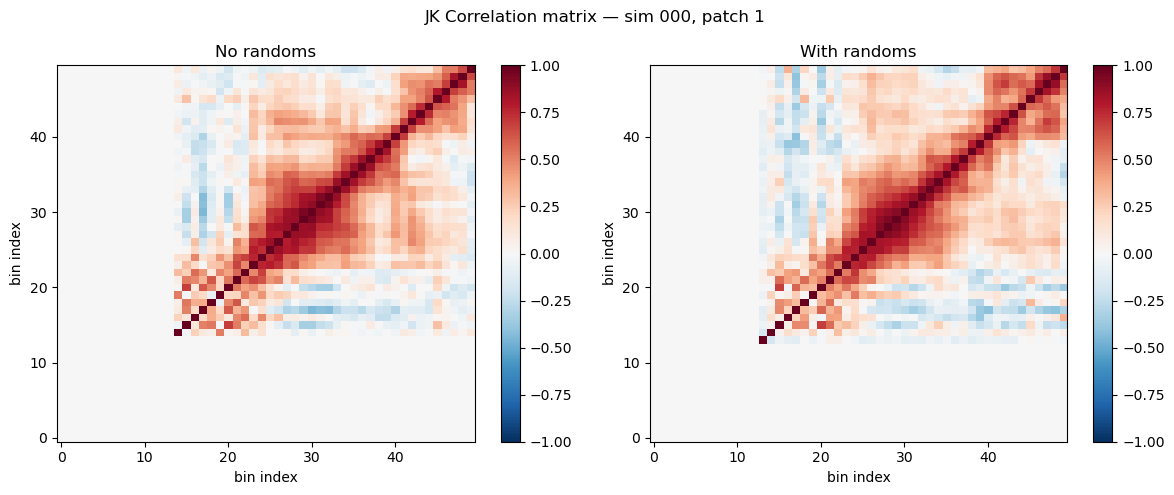

In [7]:
corr_no  = cov_to_corr(cov_no)
corr_ran = cov_to_corr(cov_ran)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, corr, title in zip(axes, [corr_no, corr_ran], ['No randoms', 'With randoms']):
    im = ax.imshow(corr, origin='lower', aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
    plt.colorbar(im, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('bin index')
    ax.set_ylabel('bin index')

fig.suptitle(f'JK Correlation matrix — sim {SIM}, patch {patch_id}')
plt.tight_layout()
plt.show()

## 6. Diagonal variance comparison

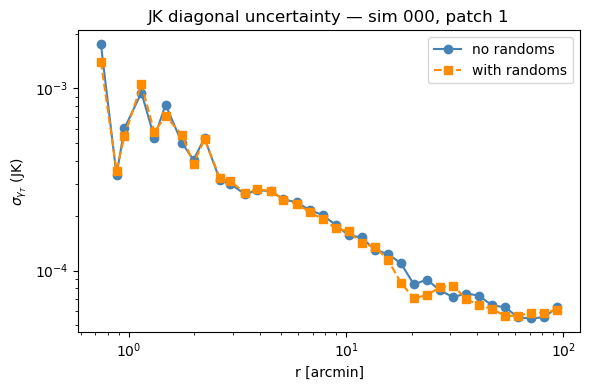

In [8]:
dv = load_datavector(DIR_NO_RAN, SIM, PATCH_N, patch_id)
mask = dv['npairs'] > 0
r = dv['meanr'][mask]

diag_no  = np.diag(cov_no)[mask]
diag_ran = np.diag(cov_ran)[mask]

plt.figure(figsize=(6, 4))
plt.plot(r, np.sqrt(diag_no),  'o-', label='no randoms',   color='steelblue')
plt.plot(r, np.sqrt(diag_ran), 's--', label='with randoms', color='darkorange')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('r [arcmin]')
plt.ylabel(r'$\sigma_{\gamma_T}$ (JK)')
plt.title(f'JK diagonal uncertainty — sim {SIM}, patch {patch_id}')
plt.legend()
plt.tight_layout()
plt.show()

## 7. S/N: gamT / sigma_gamT

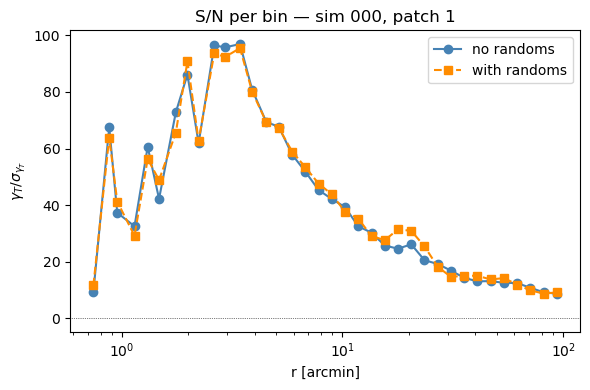

In [9]:
gamT_no  = dv_no['gamT'][mask]
gamT_ran = dv_ran['gamT'][mask]

plt.figure(figsize=(6, 4))
plt.plot(r, gamT_no  / np.sqrt(diag_no),  'o-', label='no randoms',   color='steelblue')
plt.plot(r, gamT_ran / np.sqrt(diag_ran), 's--', label='with randoms', color='darkorange')
plt.axhline(0, color='k', lw=0.5, ls=':')
plt.xscale('log')
plt.xlabel('r [arcmin]')
plt.ylabel(r'$\gamma_T / \sigma_{\gamma_T}$')
plt.title(f'S/N per bin — sim {SIM}, patch {patch_id}')
plt.legend()
plt.tight_layout()
plt.show()